# Data Visualization - Lesson 3: Advanced Business Visualization

**Session length:** 6 hours  
**Theme:** Multi-dimensional analysis, deeper business diagnostics, storytelling with visualizations, critique and improvement of charts, and a larger capstone-style analysis.

This notebook uses the **Sample Superstore** retail dataset and is designed as a practical, discussion-driven class session.

## Learning goals
By the end of this session, students should be able to:
1. Analyze business performance across multiple dimensions at the same time.
2. Diagnose performance problems using charts rather than just describe them.
3. Turn analysis into a simple visual story with a beginning, middle, and recommendation.
4. Critique weak charts and redesign them more clearly.
5. Conduct a larger capstone-style business analysis using visualization and pandas.

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Seaborn style
sns.set_theme()


## Load the dataset

This lesson uses the **Sample Superstore** dataset, a classic retail dataset for business analysis.

The notebook first tries to load a local file named `superstore.csv`.  
If that file is not available, it falls back to a public raw CSV link.


In [ ]:
df = pd.read_csv('superstore.csv', encoding="latin1")
# Basic cleaning
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Add time helper columns
df["Order Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["Order Year"] = df["Order Date"].dt.year
df["Order Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

df.head()


Loaded from URL


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Quarter
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91,2017-11-01,"2,017.00",2017Q4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58,2017-11-01,"2,017.00",2017Q4
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87,2017-06-01,"2,017.00",2017Q2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03,2016-10-01,"2,016.00",2016Q4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52,2016-10-01,"2,016.00",2016Q4


In [5]:
# Quick structure review
print(df.shape)
print()
print(df.dtypes)


(10800, 24)

Row ID                      str
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
Order Month      datetime64[us]
Order Year              float64
Order Quarter               str
dtype: object


In [6]:
# Missing values check
df.isna().sum().sort_values(ascending=False)


Postal Code      817
Ship Date        806
Customer ID      806
Order Date       806
Customer Name    806
Segment          806
Country          806
Ship Mode        806
Product Name     806
Sales            806
City             806
State            806
Region           806
Product ID       806
Category         806
Sub-Category     806
Profit           806
Order Month      806
Quantity         806
Discount         806
Order Year       806
Order Quarter    806
Order ID           0
Row ID             0
dtype: int64

## Quick business context

Each row is an order line.  
A line has:
- a product
- a customer segment
- a location
- sales
- discount
- profit

This means one chart can answer a simple question, but a combination of charts can answer a management question such as:

> Which regions and categories create revenue, but destroy profit when discounts rise?


## Part 1. Warm-up review: what should an advanced analyst do?

A beginner often asks:
- Which category has the highest sales?

An advanced analyst asks:
- Which category has the highest sales **and** weak profit?
- Does that pattern vary by region?
- Is discount part of the explanation?
- Is the problem broad, or concentrated in a few sub-categories?
- Is the issue getting better or worse over time?


## Part 2. Multi-dimensional analysis

### 2.1 Category by region: sales and profit together

A single dimension is usually not enough.  
Business performance often changes when we split by both:
- **product dimension** (category / sub-category)
- **market dimension** (region / segment)


In [7]:
category_region = (
    df.groupby(["Region", "Category"], as_index=False)
      .agg(total_sales=("Sales", "sum"),
           total_profit=("Profit", "sum"),
           avg_discount=("Discount", "mean"),
           orders=("Order ID", "nunique"))
)

category_region


,Region,Category,total_sales,total_profit,avg_discount,orders
0,Central,Furniture,"163,797.16","-2,871.05",0.30,403
1,Central,Office Supplies,"167,026.42","8,879.98",0.25,880
2,Central,Technology,"170,416.31","33,697.43",0.13,356
3,East,Furniture,"208,291.20","3,046.17",0.15,488
4,East,Office Supplies,"205,516.05","41,014.58",0.14,1074
5,East,Technology,"264,973.98","47,462.04",0.14,443
6,South,Furniture,"117,298.68","6,771.21",0.12,278
7,South,Office Supplies,"125,651.31","19,986.39",0.17,619
8,South,Technology,"148,771.91","19,991.83",0.11,255
9,West,Furniture,"252,612.74","11,504.95",0.13,595


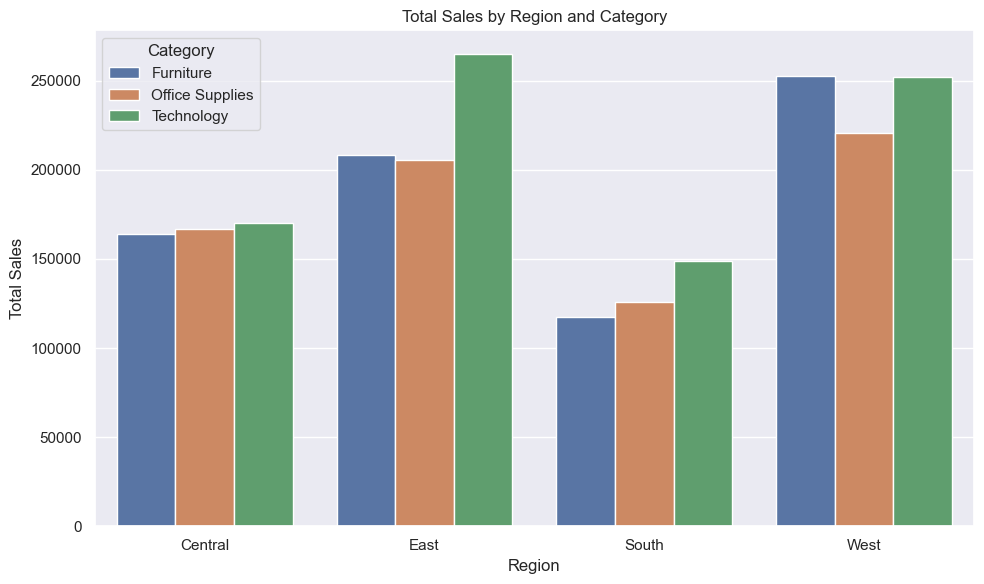

In [8]:
# Compare sales by region and category
plt.figure(figsize=(10, 6))
sns.barplot(data=category_region, x="Region", y="total_sales", hue="Category")
plt.title("Total Sales by Region and Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


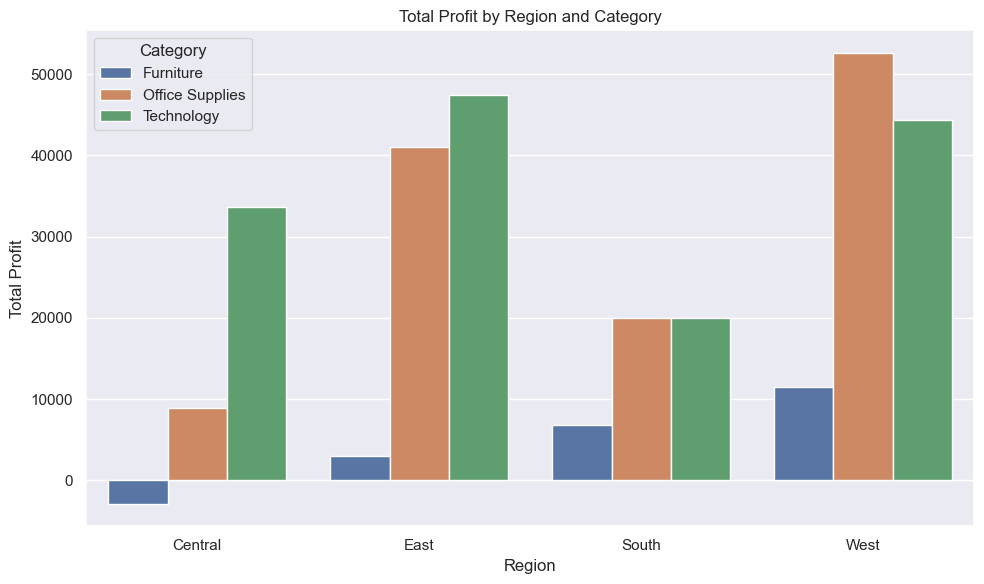

In [9]:
# Compare profit by region and category
plt.figure(figsize=(10, 6))
sns.barplot(data=category_region, x="Region", y="total_profit", hue="Category")
plt.title("Total Profit by Region and Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


### Reflection questions
1. Does the category with the highest sales also have the highest profit?
2. Is any category strong in one region but weak in another?
3. If a category sells well but profits poorly, what explanations are possible?


### 2.2 Heatmap for multi-dimensional comparison

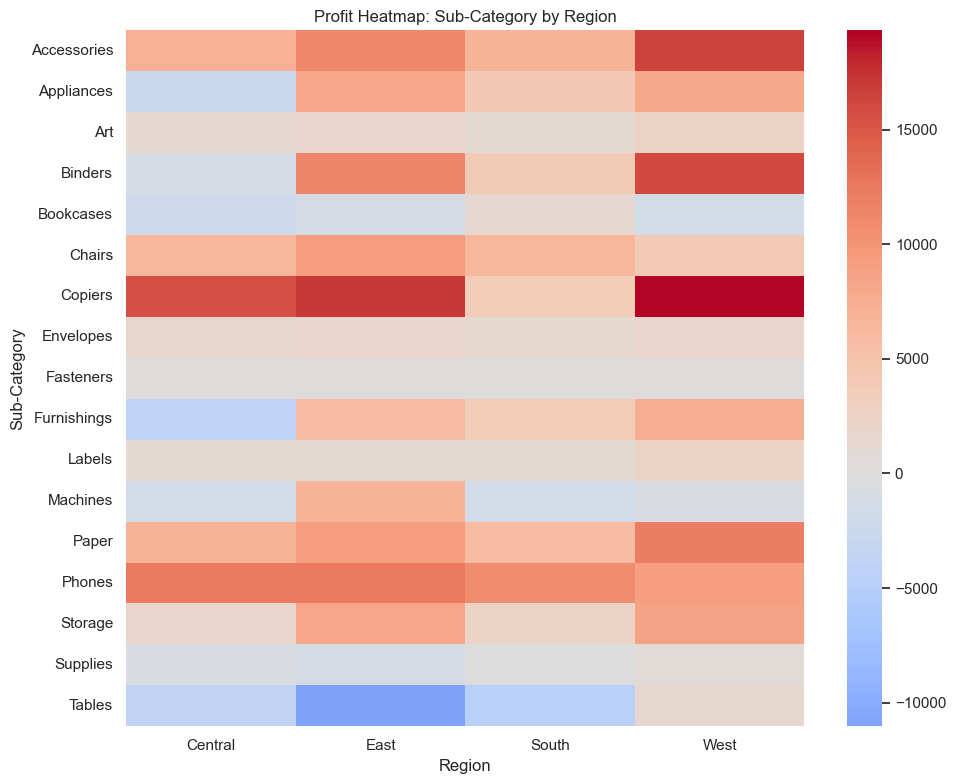

In [10]:
profit_pivot = (
    df.pivot_table(index="Sub-Category", columns="Region", values="Profit", aggfunc="sum")
      .fillna(0)
)

plt.figure(figsize=(10, 8))
sns.heatmap(profit_pivot, annot=False, cmap="coolwarm", center=0)
plt.title("Profit Heatmap: Sub-Category by Region")
plt.tight_layout()
plt.show()


Why this chart matters:

A bar chart is good for a small number of groups.  
A **heatmap** is often better when we want to compare many combinations at once.

This is a classic multi-dimensional analysis chart because it helps students see:
- concentration
- strong areas
- weak areas
- negative profit pockets


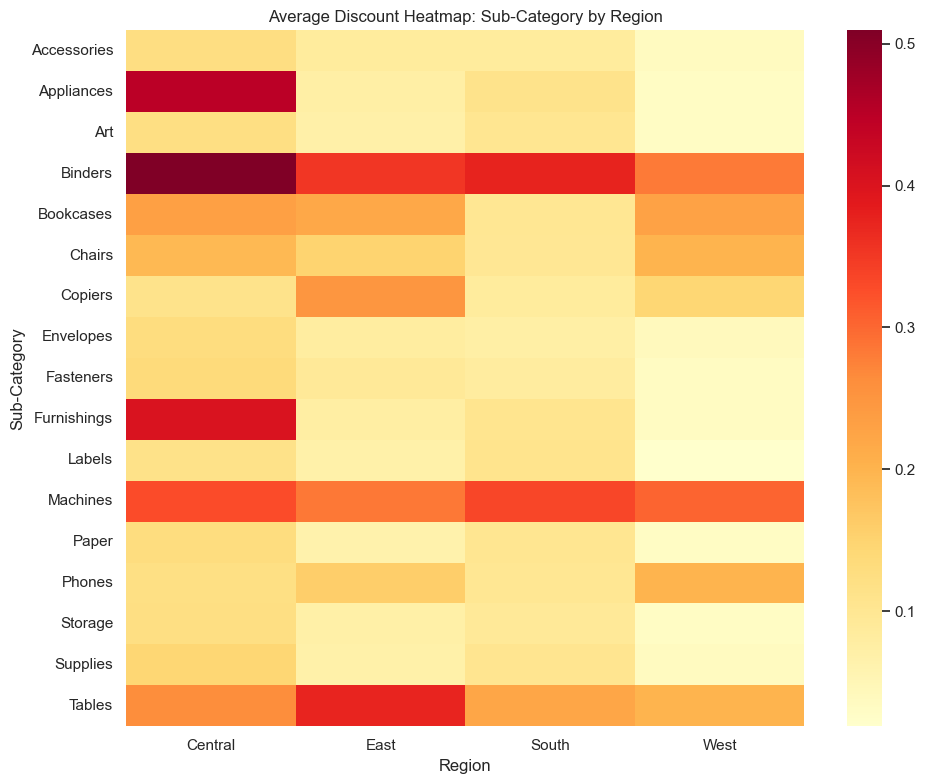

In [11]:
# Same idea for average discount
discount_pivot = (
    df.pivot_table(index="Sub-Category", columns="Region", values="Discount", aggfunc="mean")
      .fillna(0)
)

plt.figure(figsize=(10, 8))
sns.heatmap(discount_pivot, annot=False, cmap="YlOrRd")
plt.title("Average Discount Heatmap: Sub-Category by Region")
plt.tight_layout()
plt.show()


### Discussion
Now compare the two heatmaps:
- Do high-discount areas line up with low-profit areas?
- Are there exceptions?
- What would you investigate next?


### 2.3 Segment-level perspective

In [12]:
segment_summary = (
    df.groupby(["Segment", "Category"], as_index=False)
      .agg(total_sales=("Sales", "sum"),
           total_profit=("Profit", "sum"),
           avg_discount=("Discount", "mean"))
)

segment_summary


,Segment,Category,total_sales,total_profit,avg_discount
0,Consumer,Furniture,"391,049.31","6,991.08",0.18
1,Consumer,Office Supplies,"363,952.14","56,330.32",0.16
2,Consumer,Technology,"406,399.90","70,797.81",0.13
3,Corporate,Furniture,"229,019.79","7,584.82",0.17
4,Corporate,Office Supplies,"230,676.46","40,227.32",0.16
5,Corporate,Technology,"246,450.12","44,167.00",0.13
6,Home Office,Furniture,"121,930.70","3,875.38",0.17
7,Home Office,Office Supplies,"124,418.43","25,933.16",0.15
8,Home Office,Technology,"183,304.02","30,490.14",0.13


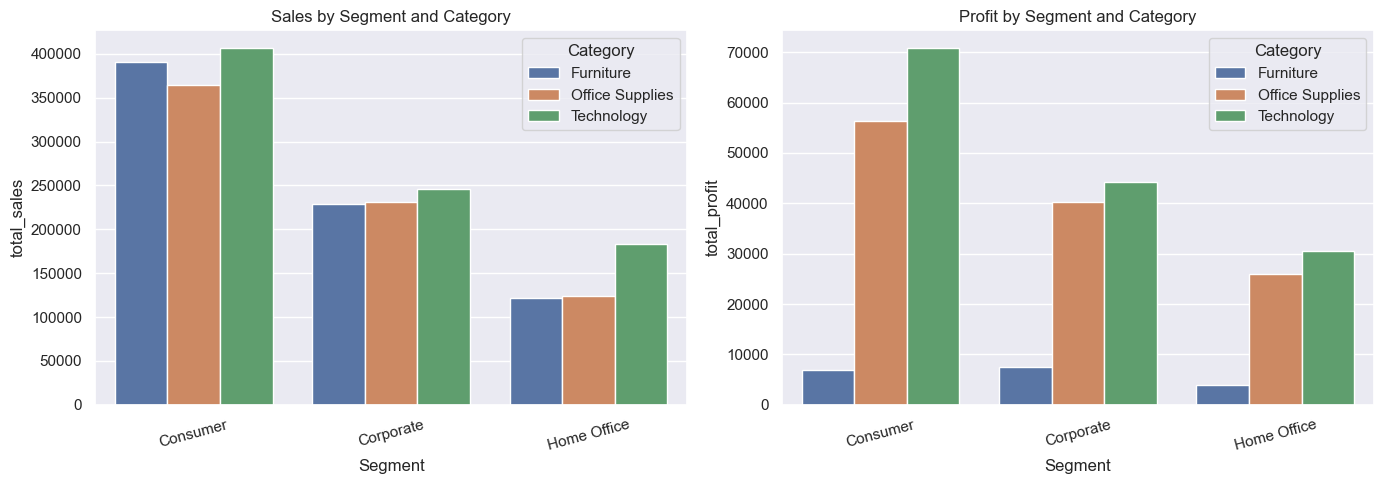

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=segment_summary, x="Segment", y="total_sales", hue="Category", ax=axes[0])
axes[0].set_title("Sales by Segment and Category")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=segment_summary, x="Segment", y="total_profit", hue="Category", ax=axes[1])
axes[1].set_title("Profit by Segment and Category")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


### Mini exercise
Write 2-3 business observations from the segment analysis.

Try to go beyond:
- "Consumer has high sales."

Instead say:
- "Consumer appears to drive the most sales, but we should compare its profit efficiency because high volume does not automatically mean strong business quality."


## Part 3. Deeper business diagnostics

This section goes beyond description and moves into diagnosis.

A diagnostic question sounds like:
- Why is profit weak?
- Where is the problem concentrated?
- What patterns are associated with the problem?


### 3.1 Discount vs profit: relationship analysis

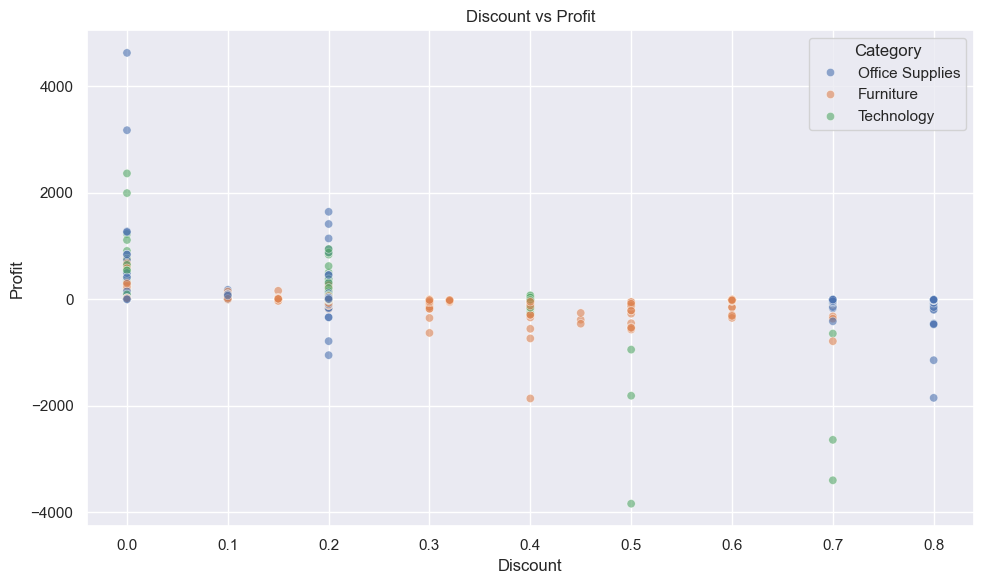

In [14]:
sample_df = df.dropna(subset=["Discount", "Profit", "Sales"]).sample(2500, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6
)
plt.title("Discount vs Profit")
plt.tight_layout()
plt.show()


In [15]:
# Correlation matrix for a few numeric variables
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
df[numeric_cols].corr()


,Sales,Quantity,Discount,Profit
Sales,1.00,0.20,-0.03,0.48
Quantity,0.20,1.00,0.01,0.07
Discount,-0.03,0.01,1.00,-0.22
Profit,0.48,0.07,-0.22,1.00


### Important interpretation note

Correlation helps, but it does **not** prove causation.

A manager should not say:
- "Discount causes all losses."

A better statement is:
- "Higher discounts are associated with weaker profitability in many cases, so discount policy is an important factor to investigate."


### 3.2 Find loss-making sub-categories

In [16]:
loss_by_subcat = (
    df.groupby("Sub-Category", as_index=False)
      .agg(total_sales=("Sales", "sum"),
           total_profit=("Profit", "sum"),
           avg_discount=("Discount", "mean"),
           orders=("Order ID", "nunique"))
      .sort_values("total_profit")
)

loss_by_subcat.head(10)


,Sub-Category,total_sales,total_profit,avg_discount,orders
16,Tables,"206,965.53","-17,725.48",0.26,307
4,Bookcases,"114,880.00","-3,472.56",0.21,224
15,Supplies,"46,673.54","-1,189.10",0.08,187
8,Fasteners,"3,024.28",949.52,0.08,215
11,Machines,"189,238.63","3,384.76",0.31,112
10,Labels,"12,486.31","5,546.25",0.07,346
2,Art,"27,118.79","6,527.79",0.07,731
7,Envelopes,"16,476.40","6,964.18",0.08,249
9,Furnishings,"91,705.16","13,059.14",0.14,877
1,Appliances,"107,532.16","18,138.01",0.17,451


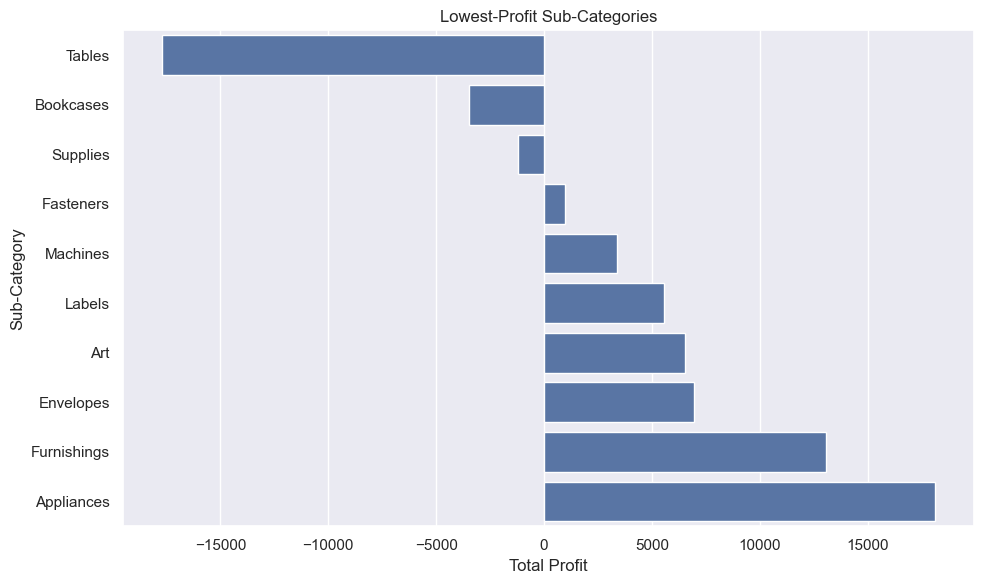

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=loss_by_subcat.head(10),
    x="total_profit",
    y="Sub-Category"
)
plt.title("Lowest-Profit Sub-Categories")
plt.xlabel("Total Profit")
plt.tight_layout()
plt.show()


### Discussion prompt
For the weakest sub-categories:
- Are they weak because of low sales?
- Or because they sell a lot but lose money?
- Is discount high?
- Could shipping, product mix, or pricing be part of the issue?


### 3.3 Trend diagnostics over time

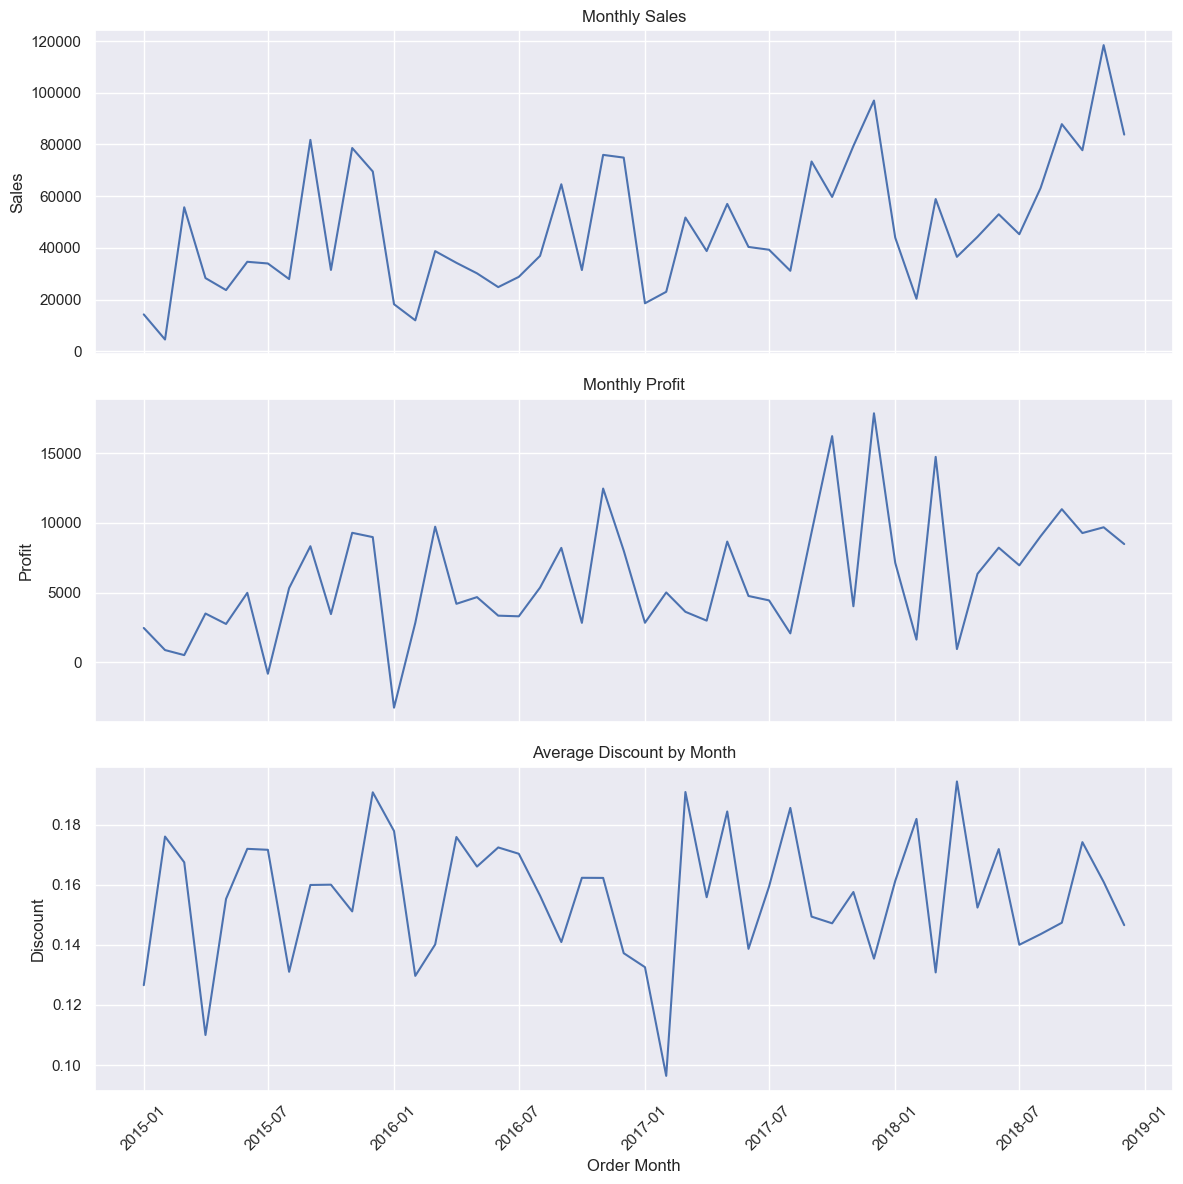

In [23]:
# -----------------------------
# Data Preparation: Monthly Aggregation
# -----------------------------

# Group data by "Order Month" and compute multiple metrics at once
monthly = (
    df
    .groupby("Order Month", as_index=False)   # group data by month (keep as column, not index)
    
    # .agg() allows multiple aggregations on different columns
    # Format: new_column_name = (original_column, aggregation_function)
    .agg(
        total_sales=("Sales", "sum"),        # total sales per month
        total_profit=("Profit", "sum"),      # total profit per month
        avg_discount=("Discount", "mean")    # average discount per month
    )
)

# -----------------------------
# Subplots: 3 Rows, 1 Column (Stacked Vertically)
# -----------------------------

# Create 3 vertically stacked subplots
# - sharex=True means all plots share the same x-axis (important for time series)
# - makes comparison across plots easier
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# axes is an array: axes[0], axes[1], axes[2]


# -----------------------------
# First Subplot: Monthly Sales
# -----------------------------

axes[0].plot(
    monthly["Order Month"],       # x-axis: time (month)
    monthly["total_sales"]        # y-axis: total sales
)
axes[0].set_title("Monthly Sales")
axes[0].set_ylabel("Sales")


# -----------------------------
# Second Subplot: Monthly Profit
# -----------------------------

axes[1].plot(
    monthly["Order Month"],
    monthly["total_profit"]
)
axes[1].set_title("Monthly Profit")
axes[1].set_ylabel("Profit")


# -----------------------------
# Third Subplot: Average Discount
# -----------------------------

axes[2].plot(
    monthly["Order Month"],
    monthly["avg_discount"]
)
axes[2].set_title("Average Discount by Month")
axes[2].set_ylabel("Discount")

# Only the bottom subplot needs x-axis label (since sharex=True)
axes[2].set_xlabel("Order Month")


# -----------------------------
# Final Formatting
# -----------------------------

# Rotate x-axis labels (applies to shared x-axis)
plt.xticks(rotation=45)

# Adjust spacing between subplots to avoid overlap
plt.tight_layout()

# Render all three plots together
plt.show()

### Interpretation questions
1. Are sales and profit moving together?
2. Do we see months where sales rise but profit does not?
3. Does discount seem to rise before weak-profit periods?
4. What additional chart would strengthen your explanation?


### 3.4 A manager-facing diagnostic chart

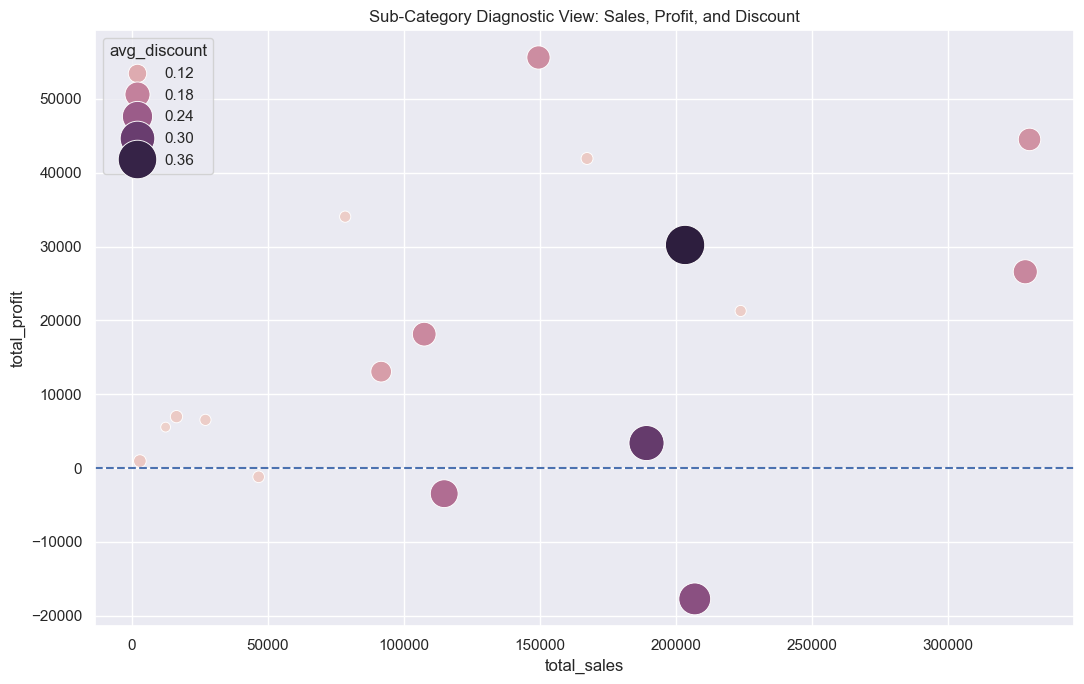

In [24]:
# -----------------------------
# Data Preparation: Sub-Category Level Metrics
# -----------------------------

# Aggregate key business metrics at the Sub-Category level
subcat_diag = (
    df
    .groupby("Sub-Category", as_index=False)   # group data by product sub-category
    
    # Compute multiple metrics for each sub-category
    .agg(
        total_sales=("Sales", "sum"),        # total sales volume
        total_profit=("Profit", "sum"),      # total profit
        avg_discount=("Discount", "mean")    # average discount applied
    )
)

# -----------------------------
# Visualization: Diagnostic Scatter Plot
# -----------------------------

# Create a figure with custom size
plt.figure(figsize=(11, 7))

# Scatter plot to analyze relationships between metrics
sns.scatterplot(
    data=subcat_diag,
    
    # X-axis: total sales (business size / volume)
    x="total_sales",
    
    # Y-axis: total profit (business outcome)
    y="total_profit",
    
    # Size of each point represents avg discount
    # Larger points = higher discount
    size="avg_discount",
    
    # Color also represents avg discount (reinforces interpretation)
    hue="avg_discount",
    
    # Control min and max point sizes
    sizes=(50, 800)
)

# Add a horizontal reference line at profit = 0
# Helps identify which sub-categories are losing money
plt.axhline(0, linestyle="--")

# Add chart title
plt.title("Sub-Category Diagnostic View: Sales, Profit, and Discount")

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()

This is a more advanced business diagnostic chart because it combines:
- **x-axis:** total sales
- **y-axis:** total profit
- **size:** average discount
- **color:** average discount

This lets us ask:
- Which sub-categories have high sales but weak profit?
- Are those also the ones with larger discounts?


## Part 4. Storytelling with visualizations

Good analysis is not just a collection of charts.  
It should tell a story.

A simple business data story often has 3 stages:

### Story structure
1. **Situation**  
   What matters overall?

2. **Complication**  
   What problem or tension appears?

3. **Resolution / recommendation**  
   What should management do next?

Let's build one.


### 4.1 Story chart 1: total company trend

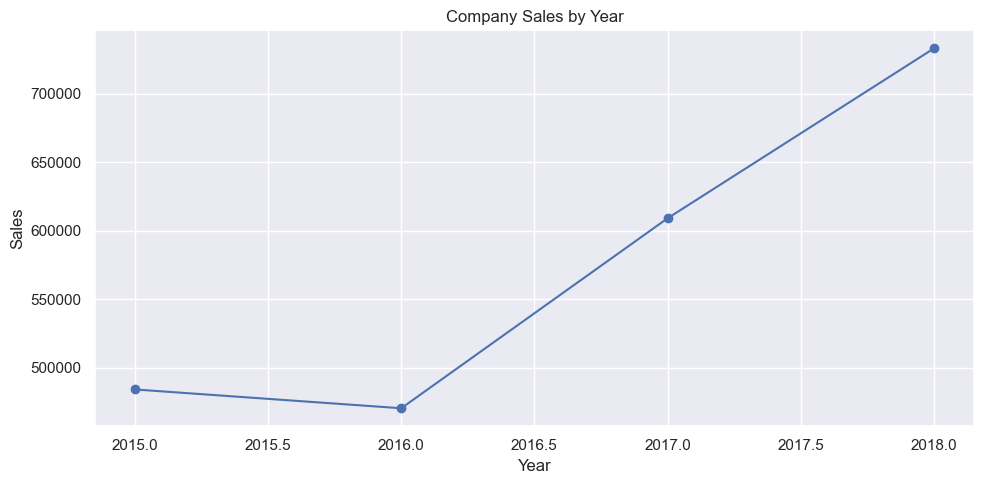

In [25]:
# -----------------------------
# Data Preparation: Yearly Aggregation
# -----------------------------

# Group data by year and compute total sales and profit
company_year = (
    df
    .groupby("Order Year", as_index=False)   # group data by year (keep as a column)
    
    # Aggregate multiple metrics
    .agg(
        total_sales=("Sales", "sum"),        # total sales per year
        total_profit=("Profit", "sum")       # total profit per year (not used yet, but prepared)
    )
)

# -----------------------------
# Visualization: Line Plot (Sales Over Time)
# -----------------------------

# Create a figure and a single axis
# - fig: the full canvas
# - ax1: the plotting area (axis)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot yearly sales as a line chart
# - marker="o" adds dots to highlight each data point (year)
ax1.plot(
    company_year["Order Year"],   # x-axis: year
    company_year["total_sales"],  # y-axis: total sales
    marker="o"
)

# Add title and axis labels
ax1.set_title("Company Sales by Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Sales")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

**Possible narration:**  
"The company is growing in sales over time. At first glance, the business appears healthy."


### 4.2 Story chart 2: weak-profit problem areas

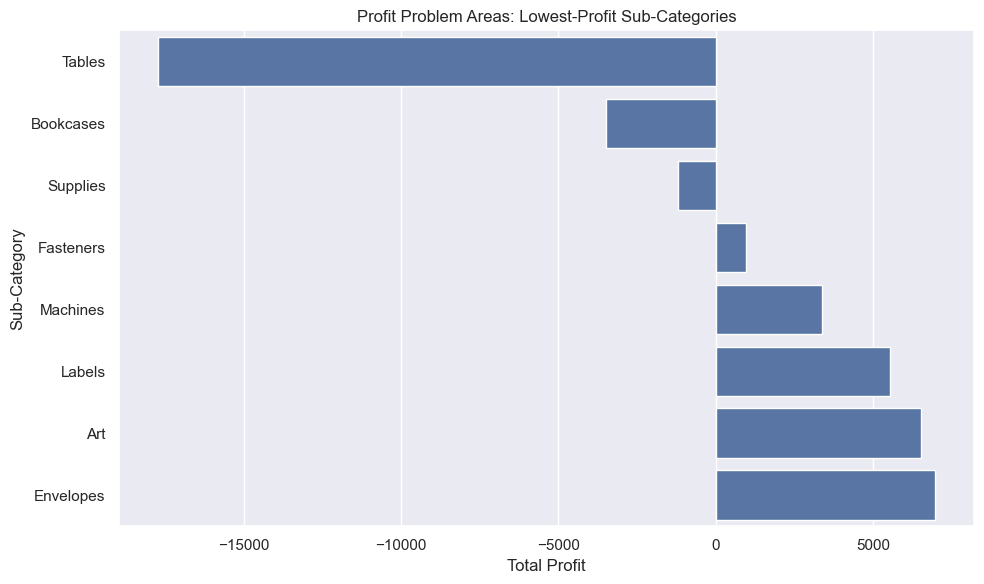

In [26]:
# -----------------------------
# Select Worst-Performing Sub-Categories
# -----------------------------

# Assume loss_by_subcat is already sorted by total_profit (ascending)
# head(8) selects the 8 sub-categories with the lowest profit (worst performers)
weak_subcats = loss_by_subcat.head(8)


# -----------------------------
# Visualization: Problem Areas (Bar Chart)
# -----------------------------

# Create a figure with custom size
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
sns.barplot(
    data=weak_subcats,
    
    # x-axis: total profit (likely negative or low values)
    x="total_profit",
    
    # y-axis: sub-category names
    y="Sub-Category"
)

# Add descriptive title
plt.title("Profit Problem Areas: Lowest-Profit Sub-Categories")

# Label x-axis
plt.xlabel("Total Profit")

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()

**Possible narration:**  
"However, profit is not healthy everywhere. A few sub-categories are dragging results down."


### 4.3 Story chart 3: likely driver

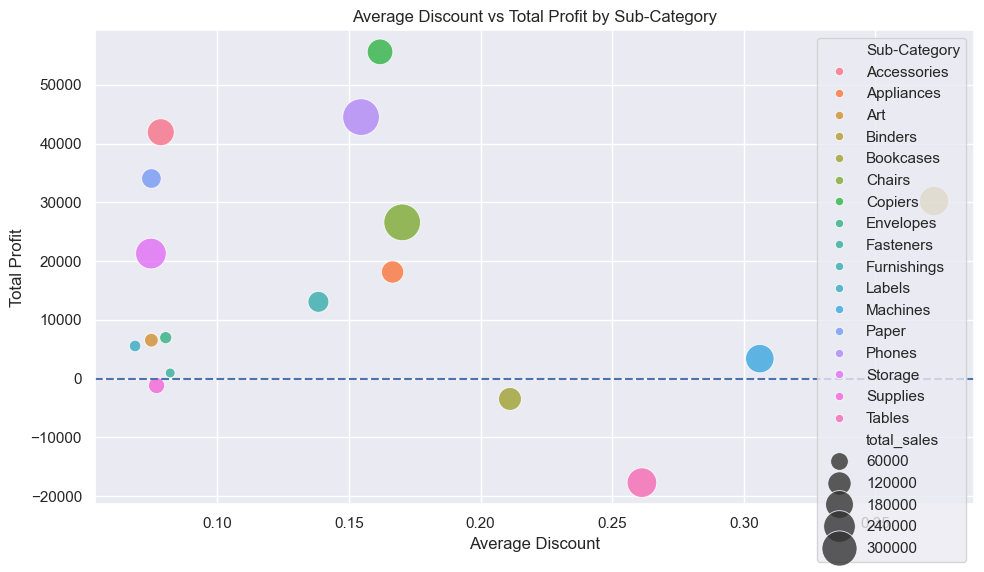

In [30]:
# -----------------------------
# Visualization: Discount vs Profit (Multi-Dimensional Scatter)
# -----------------------------

# Create a figure with custom size
plt.figure(figsize=(10, 6))

# Scatter plot to analyze relationship between discounting and profitability
sns.scatterplot(
    data=subcat_diag,
    
    # X-axis: average discount level
    # Helps analyze how discounting affects outcomes
    x="avg_discount",
    
    # Y-axis: total profit
    # Key business outcome (are we making or losing money?)
    y="total_profit",
    
    # Size of points represents total sales volume
    # Larger bubbles = higher sales
    size="total_sales",
    
    # Color represents higher-level category grouping
    # Helps compare patterns across categories
    hue="Sub-Category",
    
    # Control minimum and maximum bubble sizes
    sizes=(50, 700),
    
    # Slight transparency to reduce overlap issues
    alpha=0.8
)

# Add a horizontal reference line at profit = 0
# Helps quickly identify loss-making sub-categories
plt.axhline(0, linestyle="--")

# Add title and axis labels
plt.title("Average Discount vs Total Profit by Sub-Category")
plt.xlabel("Average Discount")
plt.ylabel("Total Profit")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

**Possible narration:**  
"One likely driver is discounting. Some sub-categories with higher average discount also show weak or negative profit."

### A simple recommendation slide could say:
- Review discount policy in weak sub-categories.
- Investigate pricing, vendor cost, and promotion strategy.
- Focus first on high-sales / low-profit product groups.


### Storytelling exercise

Write a short 4-6 sentence management summary using the 3 charts above.

Template:
1. Overall, the business shows ...
2. However, ...
3. The problem seems concentrated in ...
4. A likely contributing factor is ...
5. A practical next step is ...


## Part 5. Critique and improvement of charts

A strong analyst should not only make charts.  
They should also be able to critique bad ones.

This section intentionally creates a few weaker charts and then improves them.


### 5.1 Example of a cluttered chart

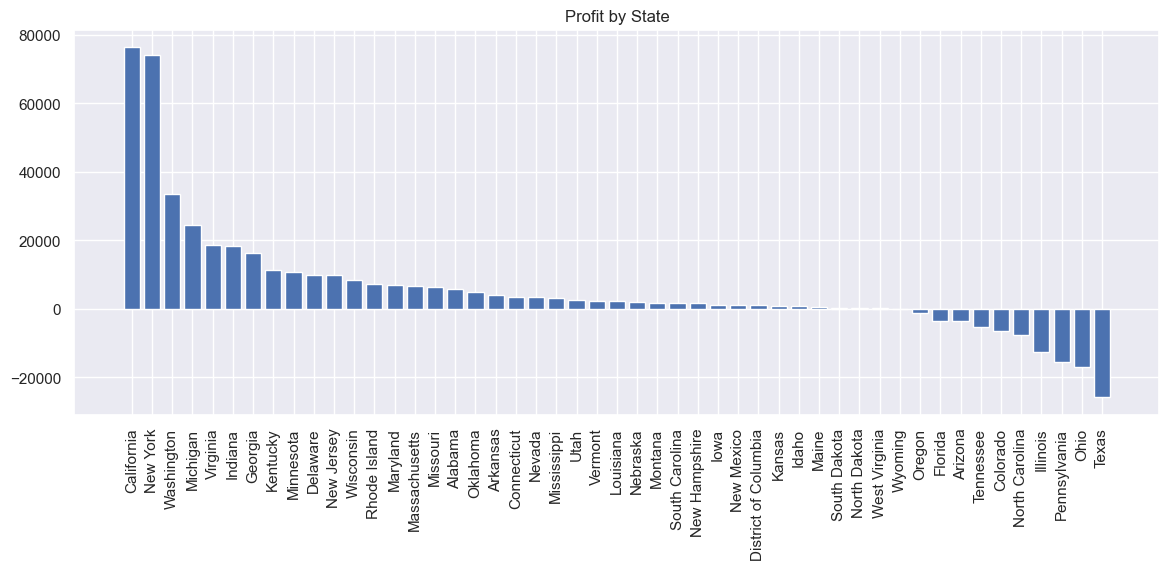

In [31]:
# -----------------------------
# Data Preparation: Profit by State
# -----------------------------

# Aggregate total profit for each state
state_profit = (
    df
    .groupby("State", as_index=False)          # group data by state
    .agg(total_profit=("Profit", "sum"))       # compute total profit per state
    
    # Sort states by profit (highest to lowest)
    .sort_values("total_profit", ascending=False)
)

# -----------------------------
# Visualization: Intentionally Crowded Chart
# -----------------------------

# Create a wide figure (but still not enough for many states)
plt.figure(figsize=(14, 5))

# Create a bar chart
# - x-axis: states (many categories → leads to crowding)
# - y-axis: total profit
plt.bar(state_profit["State"], state_profit["total_profit"])

# Add title
plt.title("Profit by State")

# Rotate x-axis labels to try to improve readability
# (still not ideal when there are too many categories)
plt.xticks(rotation=90)

# Display the chart
plt.show()

### Critique questions
- Is this chart technically wrong?
- Is it easy to read?
- What makes it hard to use?
- What business question is it trying to answer?
- Could a filtered or sorted version be better?


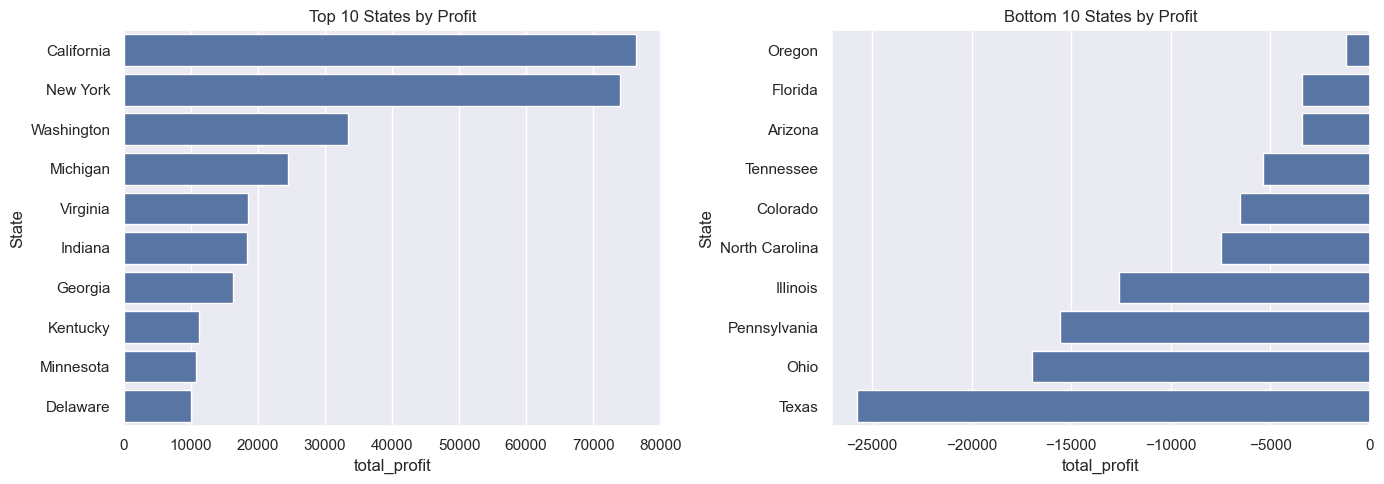

In [32]:
# -----------------------------
# Select Top and Bottom Performers
# -----------------------------

# Top 10 states with highest profit
top_states = state_profit.head(10)

# Bottom 10 states with lowest profit
# (since data is sorted descending, tail() gives worst performers)
bottom_states = state_profit.tail(10)


# -----------------------------
# Subplots: Compare Best vs Worst
# -----------------------------

# Create a figure with 2 side-by-side subplots
# - axes[0]: top performers
# - axes[1]: bottom performers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# -----------------------------
# Left Plot: Top 10 States
# -----------------------------

sns.barplot(
    data=top_states,
    
    # x-axis: profit (magnitude)
    x="total_profit",
    
    # y-axis: state names (horizontal layout improves readability)
    y="State",
    
    ax=axes[0]   # draw on first subplot
)

axes[0].set_title("Top 10 States by Profit")


# -----------------------------
# Right Plot: Bottom 10 States
# -----------------------------

sns.barplot(
    data=bottom_states,
    x="total_profit",
    y="State",
    ax=axes[1]   # draw on second subplot
)

axes[1].set_title("Bottom 10 States by Profit")


# -----------------------------
# Final Layout
# -----------------------------

# Adjust spacing between the two plots
plt.tight_layout()

# Display both plots together
plt.show()


### Why the improved chart is better
- It matches a clearer business question.
- It reduces clutter.
- It separates top and bottom performers.
- It helps the audience notice extremes faster.


### 5.2 Pie chart critique

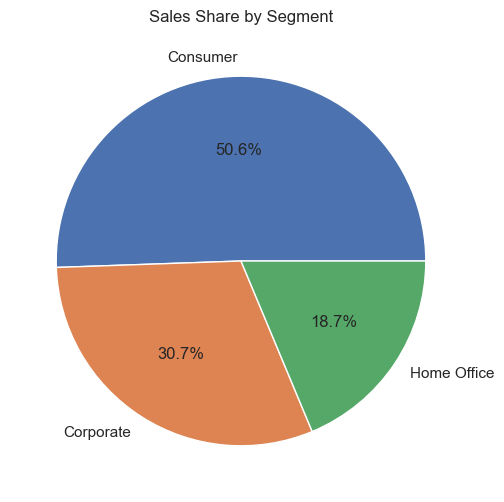

In [33]:
# -----------------------------
# Data Preparation: Sales by Segment
# -----------------------------

# Aggregate total sales for each customer segment
segment_sales = (
    df
    .groupby("Segment", as_index=False)       # group data by segment (e.g., Consumer, Corporate)
    .agg(total_sales=("Sales", "sum"))        # compute total sales per segment
)

# -----------------------------
# Visualization: Pie Chart (Sales Share)
# -----------------------------

# Create a square figure (important for pie charts to look circular)
plt.figure(figsize=(6, 6))

# Create a pie chart
plt.pie(
    segment_sales["total_sales"],             # values: total sales
    labels=segment_sales["Segment"],          # labels: segment names
    
    # Display percentages on the chart (formatted to 1 decimal place)
    autopct="%1.1f%%"
)

# Add chart title
plt.title("Sales Share by Segment")

# Display the chart
plt.show()


This pie chart is acceptable, but a bar chart often supports comparison better.


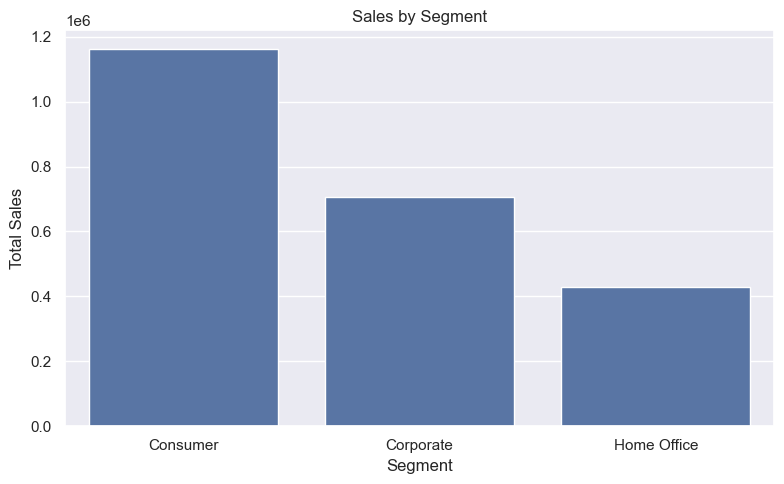

In [34]:
# -----------------------------
# Visualization: Sales by Segment (Bar Chart)
# -----------------------------

# Create a figure with specified size
plt.figure(figsize=(8, 5))

# Create a bar chart
sns.barplot(
    data=segment_sales,
    
    # x-axis: segment categories (e.g., Consumer, Corporate, Home Office)
    x="Segment",
    
    # y-axis: total sales for each segment
    y="total_sales"
)

# Add chart title
plt.title("Sales by Segment")

# Label y-axis (x-axis label is optional since categories are self-explanatory)
plt.ylabel("Total Sales")

# Adjust layout to prevent label/title overlap
plt.tight_layout()

# Display the chart
plt.show()

### Discussion
Why might the bar chart be better than the pie chart here?
- easier comparison
- easier labeling
- more precise sense of difference


### 5.3 Misleading design choices

When critiquing charts, check for:
- too many categories
- tiny fonts
- cluttered labels
- unclear titles
- decorative choices with no analytical value
- missing context
- misleading axis choices


## Part 6. Capstone-style analysis

Now students shift from guided tasks to a larger analysis.

### Capstone scenario
You are a junior analyst supporting a retail leadership team.

The VP asks:

> "Sales are growing, but profit quality seems uneven.  
> Where are our strongest and weakest areas, what seems to drive the weakness, and what actions should we prioritize?"

Your job is to use the dataset to produce:
1. a performance overview
2. a diagnosis of weak areas
3. one or two practical recommendations


### 6.1 Step 1: build an executive KPI summary

In [35]:
# -----------------------------
# KPI Summary Table
# -----------------------------

# Create a DataFrame to store key business metrics (KPIs)
kpis = pd.DataFrame({
    
    # Names of the metrics (labels)
    "metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Average Discount"
    ],
    
    # Corresponding computed values
    "value": [
        df["Sales"].sum(),              # total revenue across all transactions
        df["Profit"].sum(),             # total profit across all transactions
        
        # nunique() counts unique order IDs
        # gives total number of distinct orders (not rows)
        df["Order ID"].nunique(),
        
        df["Discount"].mean()           # average discount applied across all orders
    ]
})

# Display the KPI table
kpis

,metric,value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Total Orders,"5,015.00"
3,Average Discount,0.16


### 6.2 Step 2: identify strong and weak business areas

In [36]:
# -----------------------------
# Capstone Summary Dataset (Multi-Level Aggregation)
# -----------------------------

# Create a comprehensive summary table across multiple business dimensions
capstone_summary = (
    df
    
    # Group by multiple levels:
    # - Region → geographic view
    # - Category → high-level product grouping
    # - Sub-Category → detailed product breakdown
    .groupby(["Region", "Category", "Sub-Category"], as_index=False)
    
    # Compute multiple key metrics for each combination
    .agg(
        total_sales=("Sales", "sum"),        # total revenue
        total_profit=("Profit", "sum"),      # total profit
        avg_discount=("Discount", "mean"),   # average discount level
        
        # Count unique orders (important: avoids double-counting line items)
        orders=("Order ID", "nunique")
    )
)

# Display first few rows to inspect structure and results
capstone_summary.head()


,Region,Category,Sub-Category,total_sales,total_profit,avg_discount,orders
0,Central,Furniture,Bookcases,"24,157.18","-1,997.90",0.23,49
1,Central,Furniture,Chairs,"85,230.65","6,592.72",0.19,144
2,Central,Furniture,Furnishings,"15,254.37","-3,906.22",0.40,191
3,Central,Furniture,Tables,"39,154.97","-3,559.65",0.26,68
4,Central,Office Supplies,Appliances,"23,582.03","-2,638.62",0.45,119


In [ ]:
# Top profit generators
capstone_summary.sort_values("total_profit", ascending=False).head(10)


In [ ]:
# Worst profit performers
capstone_summary.sort_values("total_profit", ascending=True).head(10)


### 6.3 Step 3: create a capstone dashboard-style set of charts

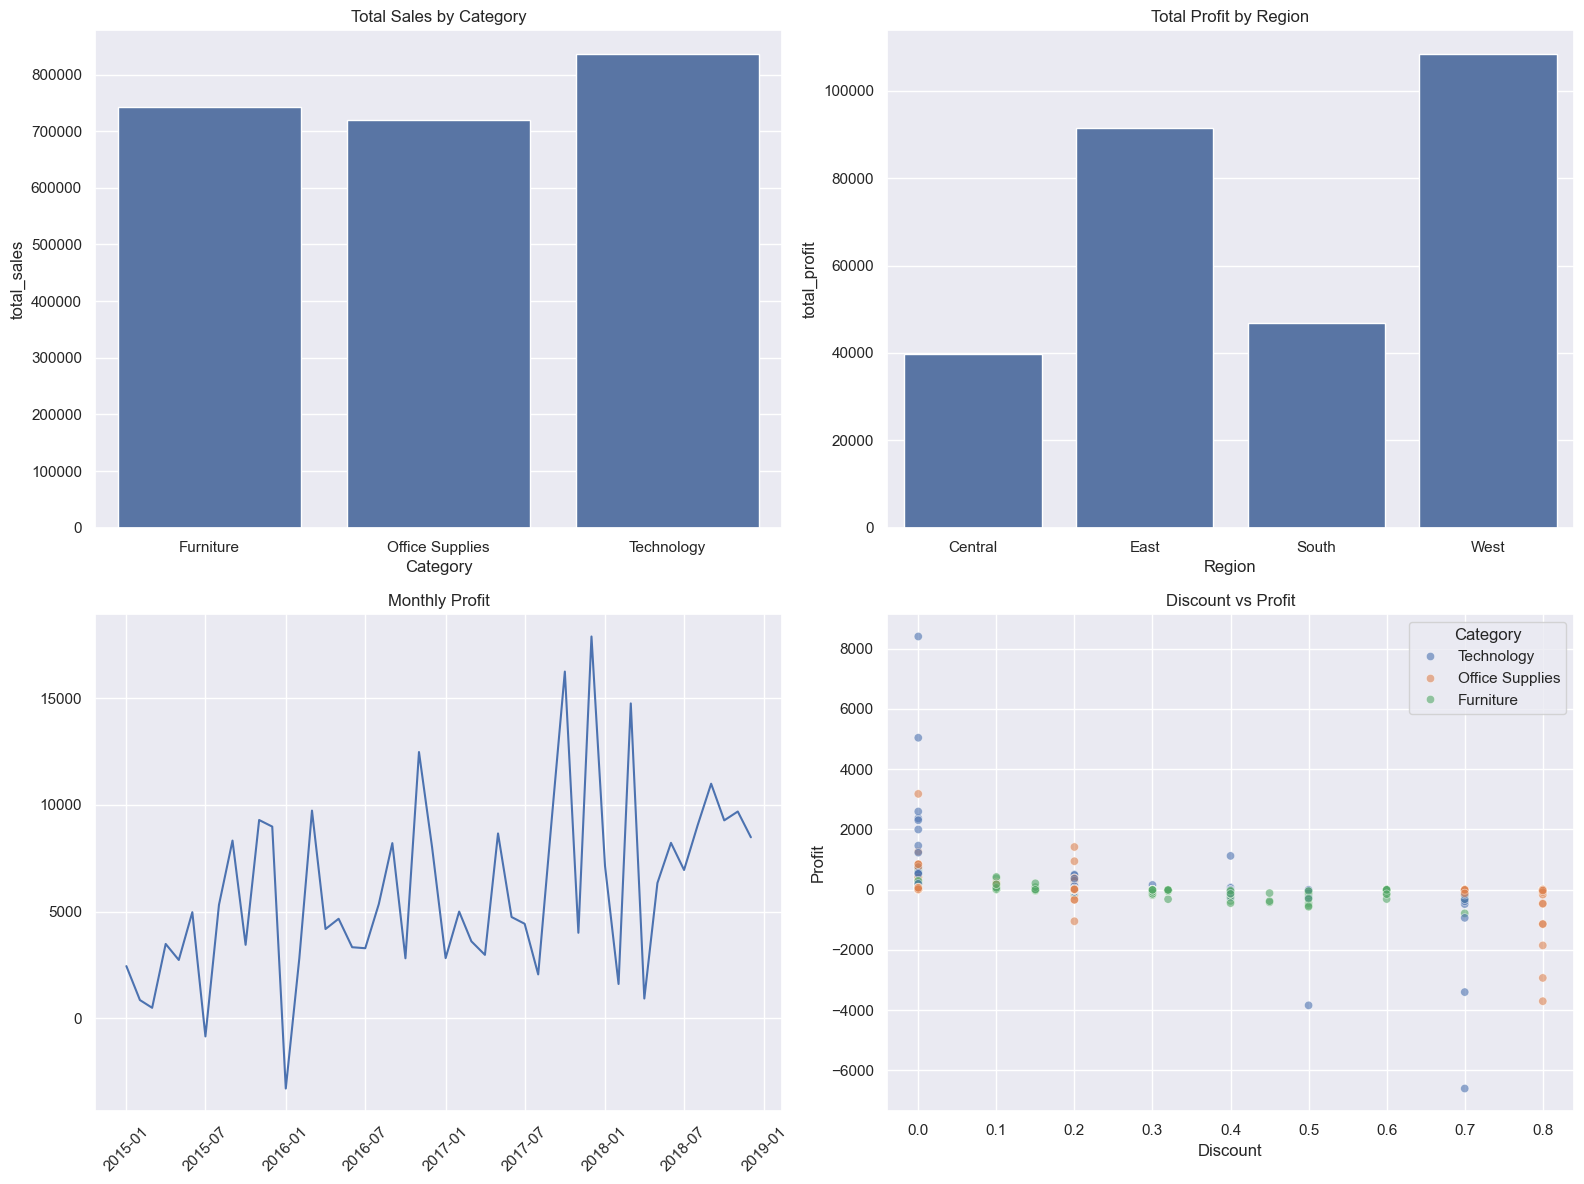

In [37]:
# -----------------------------
# Dashboard: 2x2 Grid of Charts
# -----------------------------

# Create a 2x2 grid of subplots
# - fig: full canvas
# - axes: 2D array of plots → axes[row, col]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# -----------------------------
# Chart 1: Total Sales by Category
# -----------------------------

# Aggregate total sales for each category
cat_summary = df.groupby("Category", as_index=False).agg(total_sales=("Sales", "sum"))

# Bar chart showing which categories generate the most revenue
sns.barplot(
    data=cat_summary,
    x="Category",
    y="total_sales",
    ax=axes[0, 0]   # top-left subplot
)

axes[0, 0].set_title("Total Sales by Category")


# -----------------------------
# Chart 2: Total Profit by Region
# -----------------------------

# Aggregate total profit for each region
region_summary = df.groupby("Region", as_index=False).agg(total_profit=("Profit", "sum"))

# Bar chart showing profitability across regions
sns.barplot(
    data=region_summary,
    x="Region",
    y="total_profit",
    ax=axes[0, 1]   # top-right subplot
)

axes[0, 1].set_title("Total Profit by Region")


# -----------------------------
# Chart 3: Monthly Profit Trend
# -----------------------------

# Aggregate profit over time (monthly)
monthly_profit = df.groupby("Order Month", as_index=False).agg(total_profit=("Profit", "sum"))

# Line chart showing trend over time
axes[1, 0].plot(
    monthly_profit["Order Month"],   # time (x-axis)
    monthly_profit["total_profit"]   # profit (y-axis)
)

axes[1, 0].set_title("Monthly Profit")

# Rotate x-axis labels for readability (dates can overlap)
axes[1, 0].tick_params(axis="x", rotation=45)


# -----------------------------
# Chart 4: Discount vs Profit (Sampled Data)
# -----------------------------

# Sample a subset of data for performance and clarity
# (scatter plots can be slow and cluttered with full dataset)
sample_df = df.sample(2500, random_state=42)

# Scatter plot to analyze relationship between discount and profit
sns.scatterplot(
    data=sample_df,
    x="Discount",     # discount level
    y="Profit",       # profit outcome
    hue="Category",   # color by category for comparison
    alpha=0.6,        # transparency to reduce overlap
    ax=axes[1, 1]     # bottom-right subplot
)

axes[1, 1].set_title("Discount vs Profit")


# -----------------------------
# Final Layout
# -----------------------------

# Adjust spacing between all subplots
plt.tight_layout()

# Display the full dashboard
plt.show()


### Capstone discussion guide
Ask students to answer:
1. What are the biggest positive performance areas?
2. What are the biggest negative performance areas?
3. Is the weakness broad or concentrated?
4. Do discounts appear to be part of the issue?
5. What would you recommend for the next management meeting?


### 6.4 Guided capstone tasks

#### Task A
Find the 5 sub-categories with the lowest total profit.  
Then visualize them.

#### Task B
Check whether the same weak sub-categories are weak in all regions or only some regions.

#### Task C
Identify one high-sales / low-profit area and explain why it deserves management attention.

#### Task D
Build a 3-chart visual story for an executive audience.

#### Task E
Write a short executive summary (150-250 words).


In [38]:
# -----------------------------
# Starter Analysis: Identify Weakest Sub-Categories
# -----------------------------

# Group data by Sub-Category and compute total profit
weakest_subcats = (
    df
    .groupby("Sub-Category", as_index=False)   # group data at sub-category level
    
    # Aggregate total profit for each sub-category
    .agg(total_profit=("Profit", "sum"))
    
    # Sort sub-categories by profit in ascending order
    # (lowest profit first → worst performers at the top)
    .sort_values("total_profit")
    
    # Select the bottom 5 sub-categories (lowest profit)
    .head(5)
)

# Display the result
weakest_subcats

,Sub-Category,total_profit
16,Tables,"-17,725.48"
4,Bookcases,"-3,472.56"
15,Supplies,"-1,189.10"
8,Fasteners,949.52
11,Machines,"3,384.76"


### 6.5 Extension: profit ratio analysis

In [39]:
# -----------------------------
# Data Preparation: Sales & Profit by Category/Sub-Category
# -----------------------------

# Aggregate total sales and total profit at a more detailed level
ratio_summary = (
    df
    .groupby(["Category", "Sub-Category"], as_index=False)  # group by two dimensions
    
    # Compute total sales and total profit for each group
    .agg(
        total_sales=("Sales", "sum"),
        total_profit=("Profit", "sum")
    )
)

# -----------------------------
# Feature Engineering: Profit Ratio (Margin)
# -----------------------------

# Create a new column: profit ratio
# = profit / sales → measures efficiency (how much profit per dollar of sales)
ratio_summary["profit_ratio"] = (
    ratio_summary["total_profit"] / ratio_summary["total_sales"]
)

# -----------------------------
# Identify Worst Performers by Profit Ratio
# -----------------------------

# Sort by profit ratio (ascending)
# → lowest (or negative) margins at the top = worst efficiency
ratio_summary.sort_values("profit_ratio").head(10)


,Category,Sub-Category,total_sales,total_profit,profit_ratio
3,Furniture,Tables,"206,965.53","-17,725.48",-0.09
0,Furniture,Bookcases,"114,880.00","-3,472.56",-0.03
12,Office Supplies,Supplies,"46,673.54","-1,189.10",-0.03
15,Technology,Machines,"189,238.63","3,384.76",0.02
1,Furniture,Chairs,"328,449.10","26,590.17",0.08
11,Office Supplies,Storage,"223,843.61","21,278.83",0.10
16,Technology,Phones,"330,007.05","44,515.73",0.13
2,Furniture,Furnishings,"91,705.16","13,059.14",0.14
6,Office Supplies,Binders,"203,412.73","30,221.76",0.15
4,Office Supplies,Appliances,"107,532.16","18,138.01",0.17


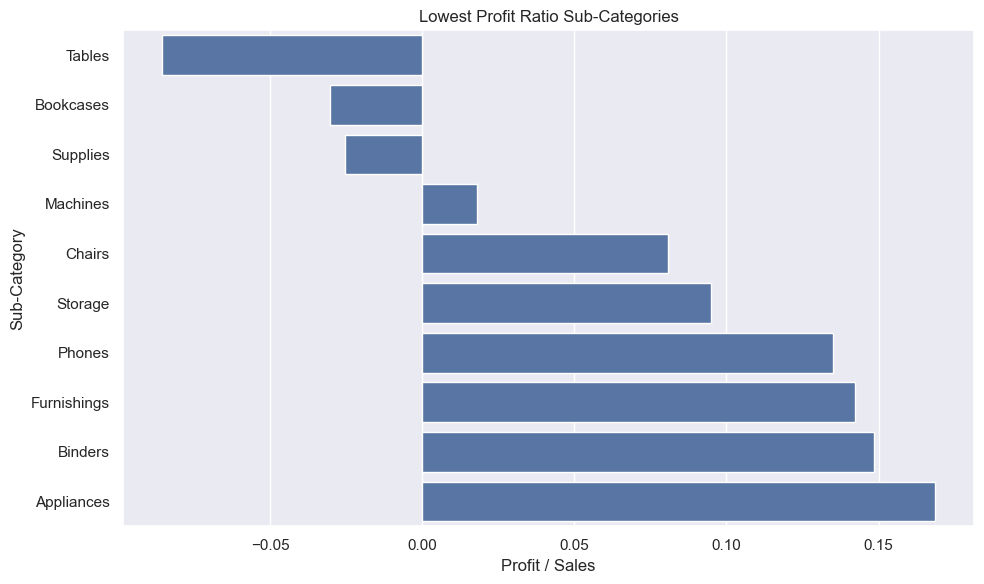

In [40]:
# -----------------------------
# Visualization: Lowest Profit Ratio Sub-Categories
# -----------------------------

# Create a figure with custom size
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
sns.barplot(
    # Sort sub-categories by profit_ratio (ascending)
    # → worst margins (lowest or negative) appear first
    data=ratio_summary.sort_values("profit_ratio").head(10),
    
    # x-axis: profit ratio (profit / sales → efficiency metric)
    x="profit_ratio",
    
    # y-axis: sub-category names
    # horizontal layout improves readability for text labels
    y="Sub-Category"
)

# Add descriptive title
plt.title("Lowest Profit Ratio Sub-Categories")

# Label x-axis to clarify meaning of the metric
plt.xlabel("Profit / Sales")

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()

This is useful because:
- total profit shows absolute weakness
- profit ratio shows efficiency weakness

A sub-category can look large and bad in absolute dollars, or small and bad in efficiency.  
Both matter, but in different ways.
